In [2]:
# ============================================
# CELL 1 - Imports
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, precision_score,
    recall_score, f1_score,
    precision_recall_curve, roc_curve,
    confusion_matrix
)
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


In [6]:
# ============================================
# CELL 2 - Load Dataset
# ============================================
cols = ['engine_id', 'cycle'] + \
       [f'setting_{i}' for i in range(1, 4)] + \
       [f'sensor_{i}' for i in range(1, 22)]

train_df = pd.read_csv(
    '../data/train_FD001.txt',
    sep='\s+',
    header=None,
    names=cols,
    engine='python'
)
train_df.dropna(axis=1, how='all', inplace=True)

# Add RUL
max_cycle = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id', 'max_cycle']
train_df = train_df.merge(max_cycle, on='engine_id')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df.drop(columns=['max_cycle'], inplace=True)

# Add labels
train_df['failure_label'] = (train_df['RUL'] < 30).astype(int)

print(f"✅ Data loaded: {train_df.shape}")
print(f"📊 Normal samples  : {(train_df['failure_label']==0).sum()}")
print(f"📊 Anomaly samples : {(train_df['failure_label']==1).sum()}")
print(f"📊 Anomaly rate    : {train_df['failure_label'].mean()*100:.2f}%")

✅ Data loaded: (20631, 28)
📊 Normal samples  : 17631
📊 Anomaly samples : 3000
📊 Anomaly rate    : 14.54%


In [7]:
# ============================================
# CELL 3 - Feature Preparation
# ============================================

# Get useful sensors only
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
sensor_cols = [c for c in sensor_cols 
               if c in train_df.columns 
               and train_df[c].std() > 0.001]

print(f"✅ Useful sensors: {len(sensor_cols)}")

# Build feature matrix
features_df = train_df[sensor_cols].copy()

# Add rolling features
for col in sensor_cols:
    features_df[f'{col}_mean5'] = train_df[col]\
        .rolling(5, min_periods=1).mean()
    features_df[f'{col}_std5'] = train_df[col]\
        .rolling(5, min_periods=1).std().fillna(0)

# Labels
features_df['true_label'] = train_df['failure_label']
features_df['RUL']        = train_df['RUL']

print(f"✅ Feature matrix shape: {features_df.shape}")
print(f"📊 Total features: {features_df.shape[1]-2}")

✅ Useful sensors: 15
✅ Feature matrix shape: (20631, 47)
📊 Total features: 45


In [13]:
# ============================================
# CELL 4 - Train Test Split
# ============================================

# Feature columns only
feature_cols = [c for c in features_df.columns
                if c not in ['true_label', 'RUL']]

# Fill any NaN values first
features_df[feature_cols] = features_df[feature_cols].fillna(0)

# ALL data for testing
X_test  = features_df[feature_cols].values
y_test  = features_df['true_label'].values

# Train on normal data only
normal_mask  = features_df['true_label'] == 0
X_normal     = features_df.loc[normal_mask, feature_cols].values
train_size   = int(len(X_normal) * 0.7)
X_train      = X_normal[:train_size]

# Scale features
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✅ X_train shape : {X_train_scaled.shape}")
print(f"✅ X_test shape  : {X_test_scaled.shape}")
print(f"✅ y_test shape  : {y_test.shape}")
print(f"✅ Anomalies     : {y_test.sum()} / {len(y_test)}")

# Verify shapes match
assert X_test_scaled.shape[0] == y_test.shape[0], "❌ Shape mismatch!"
print("✅ Shapes verified - all match!")

✅ X_train shape : (12341, 45)
✅ X_test shape  : (20631, 45)
✅ y_test shape  : (20631,)
✅ Anomalies     : 3000 / 20631
✅ Shapes verified - all match!


In [14]:
# ============================================
# CELL 5 - Train Isolation Forest 
# ============================================

mlflow.set_experiment("anomaly_detection")

print("🔄 Training Isolation Forest...")
print(f"Train size: {X_train_scaled.shape}")
print(f"Test size : {X_test_scaled.shape}")

with mlflow.start_run(run_name="IsolationForest"):

    iso = IForest(
        n_estimators=100,
        contamination=0.1,
        random_state=42
    )
    iso.fit(X_train_scaled)

    # Predict on test set
    iso_preds  = iso.predict(X_test_scaled)   # 0=normal, 1=anomaly
    iso_scores = iso.decision_function(X_test_scaled)  # anomaly scores

    # Normalize scores to 0-1
    iso_scores_norm = (iso_scores - iso_scores.min()) / \
                      (iso_scores.max() - iso_scores.min() + 1e-8)

    print(f"\n✅ Predictions shape : {iso_preds.shape}")
    print(f"✅ y_test shape      : {y_test.shape}")
    print(f"✅ Shapes match      : {iso_preds.shape == y_test.shape}")

    # Metrics
    iso_precision = precision_score(y_test, iso_preds, zero_division=0)
    iso_recall    = recall_score(y_test, iso_preds, zero_division=0)
    iso_f1        = f1_score(y_test, iso_preds, zero_division=0)
    iso_roc_auc   = roc_auc_score(y_test, iso_scores_norm)

    # Log to MLflow
    mlflow.log_params({
        "model"        : "IsolationForest",
        "n_estimators" : 100,
        "contamination": 0.1
    })
    mlflow.log_metrics({
        "precision": iso_precision,
        "recall"   : iso_recall,
        "f1_score" : iso_f1,
        "roc_auc"  : iso_roc_auc
    })
    mlflow.sklearn.log_model(iso, "isolation_forest")

    print(f"\n📊 Isolation Forest Results:")
    print(f"  Precision : {iso_precision:.4f}")
    print(f"  Recall    : {iso_recall:.4f}")
    print(f"  F1 Score  : {iso_f1:.4f}")
    print(f"  ROC-AUC   : {iso_roc_auc:.4f}")
    print("\n✅ Cell 5 Complete!")

🔄 Training Isolation Forest...
Train size: (12341, 45)
Test size : (20631, 45)

✅ Predictions shape : (20631,)
✅ y_test shape      : (20631,)
✅ Shapes match      : True


2026/04/23 13:49:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 13:49:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 Isolation Forest Results:
  Precision : 0.5956
  Recall    : 0.8547
  F1 Score  : 0.7020
  ROC-AUC   : 0.9468

✅ Cell 5 Complete!


In [16]:
# ============================================
# CELL 6 - Train Local Outlier Factor (LOF)
# ============================================

print("🔄 Training LOF...")

with mlflow.start_run(run_name="LOF"):

    lof = LOF(
        n_neighbors=20,
        contamination=0.1
    )
    lof.fit(X_train_scaled)

    # Predict
    lof_preds  = lof.predict(X_test_scaled)
    lof_scores = lof.decision_function(X_test_scaled)

    # Normalize
    lof_scores_norm = (lof_scores - lof_scores.min()) / \
                      (lof_scores.max() - lof_scores.min() + 1e-8)

    # Metrics
    lof_precision = precision_score(y_test, lof_preds, zero_division=0)
    lof_recall    = recall_score(y_test, lof_preds, zero_division=0)
    lof_f1        = f1_score(y_test, lof_preds, zero_division=0)
    lof_roc_auc   = roc_auc_score(y_test, lof_scores_norm)

    # Log to MLflow
    mlflow.log_params({
        "model"        : "LOF",
        "n_neighbors"  : 20,
        "contamination": 0.1
    })
    mlflow.log_metrics({
        "precision": lof_precision,
        "recall"   : lof_recall,
        "f1_score" : lof_f1,
        "roc_auc"  : lof_roc_auc
    })

    print(f"\n📊 LOF Results:")
    print(f"  Precision : {lof_precision:.4f}")
    print(f"  Recall    : {lof_recall:.4f}")
    print(f"  F1 Score  : {lof_f1:.4f}")
    print(f"  ROC-AUC   : {lof_roc_auc:.4f}")
    print("\n✅ Cell 6 Complete!")

🔄 Training LOF...

📊 LOF Results:
  Precision : 0.5201
  Recall    : 0.6823
  F1 Score  : 0.5903
  ROC-AUC   : 0.8618

✅ Cell 6 Complete!


In [17]:
# ============================================
# CELL 7 - Statistical Anomaly Detection
# ============================================

print("🔄 Running Statistical Methods...")

# Z-Score method
from scipy import stats

z_scores = np.abs(stats.zscore(X_test_scaled))
z_anomaly_preds = (z_scores.max(axis=1) > 3).astype(int)

# MAD method (Median Absolute Deviation)
median     = np.median(X_test_scaled, axis=0)
mad        = np.median(np.abs(X_test_scaled - median), axis=0)
mad_scores = np.abs(X_test_scaled - median) / (mad + 1e-8)
mad_preds  = (mad_scores.max(axis=1) > 3.5).astype(int)

# Metrics
z_f1   = f1_score(y_test, z_anomaly_preds, zero_division=0)
mad_f1 = f1_score(y_test, mad_preds, zero_division=0)

print(f"\n📊 Z-Score F1  : {z_f1:.4f}")
print(f"📊 MAD F1      : {mad_f1:.4f}")

with mlflow.start_run(run_name="ZScore"):
    mlflow.log_metric("f1_score", z_f1)
    mlflow.log_param("method", "zscore")

with mlflow.start_run(run_name="MAD"):
    mlflow.log_metric("f1_score", mad_f1)
    mlflow.log_param("method", "mad")

print("✅ Statistical methods done!")

🔄 Running Statistical Methods...

📊 Z-Score F1  : 0.3013
📊 MAD F1      : 0.4424
✅ Statistical methods done!


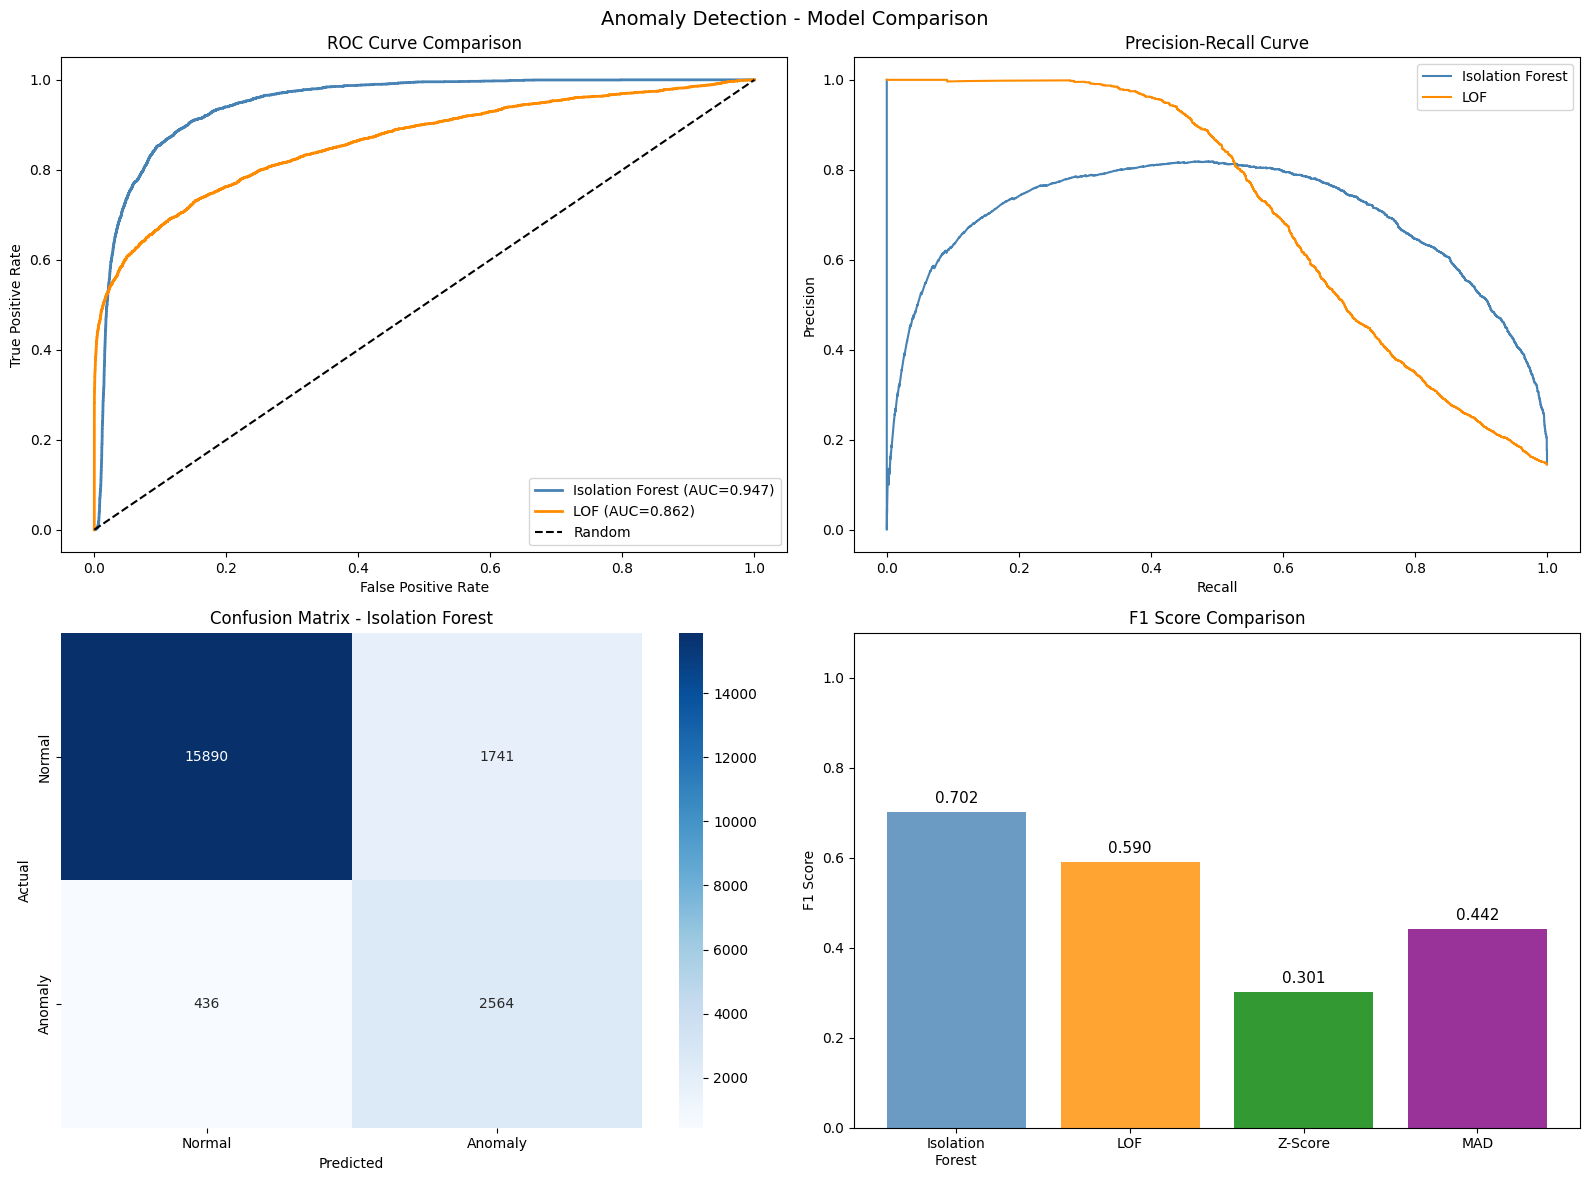

✅ Plot saved!


In [19]:
# ============================================
# CELL 8 - Plots & Comparison
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: ROC Curve
iso_fpr, iso_tpr, _ = roc_curve(y_test, iso_scores_norm)
lof_fpr, lof_tpr, _ = roc_curve(y_test, lof_scores_norm)

axes[0,0].plot(iso_fpr, iso_tpr,
               label=f'Isolation Forest (AUC={iso_roc_auc:.3f})',
               color='steelblue', linewidth=2)
axes[0,0].plot(lof_fpr, lof_tpr,
               label=f'LOF (AUC={lof_roc_auc:.3f})',
               color='darkorange', linewidth=2)
axes[0,0].plot([0,1],[0,1],'k--', label='Random')
axes[0,0].set_title('ROC Curve Comparison')
axes[0,0].set_xlabel('False Positive Rate')
axes[0,0].set_ylabel('True Positive Rate')
axes[0,0].legend()

# Plot 2: Precision-Recall Curve
iso_prec, iso_rec, _ = precision_recall_curve(y_test, iso_scores_norm)
lof_prec, lof_rec, _ = precision_recall_curve(y_test, lof_scores_norm)

axes[0,1].plot(iso_rec, iso_prec,
               label='Isolation Forest', color='steelblue')
axes[0,1].plot(lof_rec, lof_prec,
               label='LOF', color='darkorange')
axes[0,1].set_title('Precision-Recall Curve')
axes[0,1].set_xlabel('Recall')
axes[0,1].set_ylabel('Precision')
axes[0,1].legend()

# Plot 3: Confusion Matrix
iso_cm = confusion_matrix(y_test, iso_preds)
sns.heatmap(iso_cm, annot=True, fmt='d',
            cmap='Blues', ax=axes[1,0])
axes[1,0].set_title('Confusion Matrix - Isolation Forest')
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')
axes[1,0].set_xticklabels(['Normal', 'Anomaly'])
axes[1,0].set_yticklabels(['Normal', 'Anomaly'])

# Plot 4: Model Comparison Bar Chart
models    = ['Isolation\nForest', 'LOF', 'Z-Score', 'MAD']
f1_scores = [iso_f1, lof_f1, z_f1, mad_f1]
colors    = ['steelblue', 'darkorange', 'green', 'purple']

bars = axes[1,1].bar(models, f1_scores, color=colors, alpha=0.8)
axes[1,1].set_title('F1 Score Comparison')
axes[1,1].set_ylabel('F1 Score')
axes[1,1].set_ylim(0, 1.1)

# Add value labels on bars
for bar, val in zip(bars, f1_scores):
    axes[1,1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f'{val:.3f}',
        ha='center', fontsize=11
    )

plt.suptitle('Anomaly Detection - Model Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('../notebooks/anomaly_detection_comparison.png', dpi=150)
plt.show()
print("✅ Plot saved!")

In [21]:
# ============================================
# CELL 9 - Final Summary Table
# ============================================

summary = pd.DataFrame({
    'Model'    : ['Isolation Forest', 'LOF',
                  'Z-Score', 'MAD'],
    'Precision': [round(iso_precision,4),
                  round(lof_precision,4), '-', '-'],
    'Recall'   : [round(iso_recall,4),
                  round(lof_recall,4), '-', '-'],
    'F1 Score' : [round(iso_f1,4), round(lof_f1,4),
                  round(z_f1,4), round(mad_f1,4)],
    'ROC-AUC'  : [round(iso_roc_auc,4),
                  round(lof_roc_auc,4), '-', '-']
})

print("\n" + "="*60)
print("📊 FINAL ANOMALY DETECTION SUMMARY")
print("="*60)
print(summary.to_string(index=False))
print("="*60)

# Best model
best_idx   = summary['F1 Score'].replace('-', 0)\
             .astype(float).idxmax()
best_model = summary.loc[best_idx, 'Model']
print(f"\n🏆 Best Model: {best_model}")
print("\n✅ Day 5 Complete!")


📊 FINAL ANOMALY DETECTION SUMMARY
           Model Precision  Recall  F1 Score ROC-AUC
Isolation Forest    0.5956  0.8547    0.7020  0.9468
             LOF    0.5201  0.6823    0.5903  0.8618
         Z-Score         -       -    0.3013       -
             MAD         -       -    0.4424       -

🏆 Best Model: Isolation Forest

✅ Day 5 Complete!
